In [1]:
import os

from life_saving_scripts.basic_utils import set_publish_matplotlib_template
from manim_utils import get_colors
from matplotlib import pyplot as plt
import numpy as np

set_publish_matplotlib_template(mode="light")

In [2]:
from sklearn.datasets import make_classification, make_blobs
import pandas as pd
import numpy as np

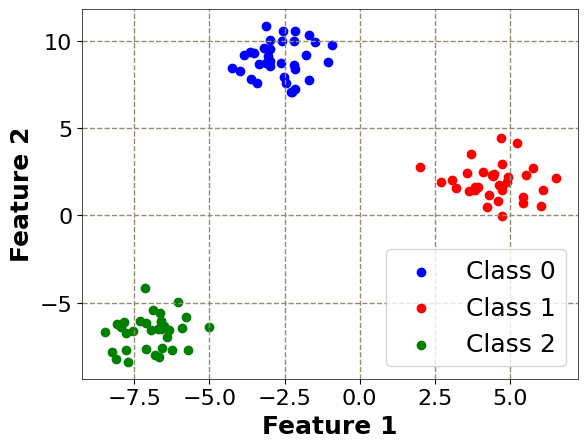

In [3]:
X, y = make_blobs(
    random_state=42, n_samples=100, n_features=2, centers=3, cluster_std=1
)

fig, ax = plt.subplots()
ax.scatter(X[y == 0, 0], X[y == 0, 1], c="blue", label="Class 0")
ax.scatter(X[y == 1, 0], X[y == 1, 1], c="red", label="Class 1")
ax.scatter(X[y == 2, 0], X[y == 2, 1], c="green", label="Class 2")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.legend()

Parameters:

- `eps`: The radius of the circle.
- `min_samples`: The number of points.


- **Core Points:** Points that have at least `min_samples` points within the radius `eps`.
- **Border Points:** Points that have less than `min_samples` points within the radius `eps`, but are within the radius of a core point.
- **Noise Points:** Points that are neither core nor border points.
- **Cluster:** A set of core points and border points that are connected.


In [4]:
points = pd.DataFrame(X, columns=["Feature 1", "Feature 2"])
points["target"] = y
points["point_type"] = "outlier"
eps = 1
min_samples = 5
points

,Feature 1,Feature 2,target,point_type
0,-7.726421,-8.394957,2,outlier
1,5.453396,0.742305,1,outlier
2,-2.978672,9.556846,0,outlier
3,6.042673,0.571319,1,outlier
4,-6.521840,-6.319325,2,outlier
...,...,...,...,...
95,-3.186120,9.625962,0,outlier
96,-1.478198,9.945566,0,outlier
97,4.478593,2.377221,1,outlier
98,-5.796576,-5.826308,2,outlier


In [76]:
class DBSCAN:

    def __init__(self, eps=1, min_samples=5):
        self.eps = eps
        self.min_samples = min_samples

    def find_points_within_distance(
        self, idx, X: pd.DataFrame, distance_matrix: np.ndarray
    ):
        distance_array = distance_matrix[idx]
        mask = distance_array < self.eps
        df = X[mask]
        # remove the self point
        return df[df.index != idx]

    def create_distance_matrix(self, X: pd.DataFrame):
        distance_matrix = np.zeros((len(X), len(X)))
        for i in range(len(X)):
            for j in range(len(X)):
                distance_matrix[i, j] = np.linalg.norm(X.iloc[i] - X.iloc[j])
        return distance_matrix

    def classify_point_type(self, X: pd.DataFrame, distance_matrix: np.ndarray):
        core_points = []
        for i in range(X.shape[0]):
            if (
                len(self.find_points_within_distance(i, X, distance_matrix))
                >= min_samples
            ):
                core_points.append(i)

        border_points = []
        for i in range(X.shape[0]):
            if i not in core_points:
                if (
                    len(
                        self.find_points_within_distance(
                            i, X, distance_matrix
                        )
                    )
                    > 0
                ):
                    border_points.append(i)

        X["point_type"] = "outlier"
        X.loc[core_points, "point_type"] = "core"
        X.loc[border_points, "point_type"] = "border"
        return X

    def expand_cluster(self, idx, X, cluster, points_seen_till_now, distance_matrix):
        if idx in points_seen_till_now:
            return cluster
        
        points_seen_till_now.add(idx)
        cluster.append(idx)
        neighbors = self.find_points_within_distance(idx, X, distance_matrix)
        for neighbor in neighbors.index:
            self.expand_cluster(neighbor,X, cluster, points_seen_till_now, distance_matrix)
        return cluster
    
    def fit(self, X: pd.DataFrame):
        distance_matrix = self.create_distance_matrix(X)
        X = self.classify_point_type(X, distance_matrix)
        clusters = []
        points_seen_till_now = set()

        for i in range(X.shape[0]):

            if i in points_seen_till_now:
                continue
            if X.loc[i, "point_type"] == "outlier":
                continue

            neighbors = self.find_points_within_distance(i, X, distance_matrix)

            if len(neighbors) < min_samples: # outliers
                continue
            cluster = self.expand_cluster(i, X, [], points_seen_till_now, distance_matrix)
            clusters.append(cluster)

        for i, indices in enumerate(clusters):
            X.loc[indices, "cluster"] = i

        X["cluster"] = X["cluster"].fillna(-1)
        X["cluster"] = X["cluster"].astype(int)
        return X

In [90]:
points = pd.DataFrame(X, columns=["Feature 1", "Feature 2"])
dbscan = DBSCAN(eps=1, min_samples=5)
points = dbscan.fit(points)

In [91]:
points["cluster"].value_counts()

cluster
 1    34
 0    32
 2    29
-1     5
Name: count, dtype: int64

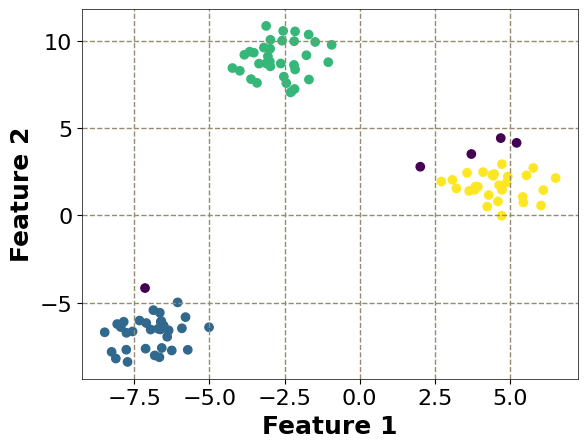

In [92]:
fig, ax = plt.subplots()
x = points["Feature 1"]
y = points["Feature 2"]
colors = points["cluster"]
ax.scatter(x, y, c=colors, cmap="viridis", label="Clusters")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")

plt.show()